# Comparative Analysis of Sales Prediction Using Machine Learning Techniques

**College Mini Project**

In this notebook we predict the **sales amount** of an order using three machine learning
regression models and compare which one works best.

| | |
|---|---|
| **Dataset** | Sample Sales Data (public Kaggle dataset), 2823 orders |
| **Target** | `SALES` — the revenue of an order |
| **Models** | Linear Regression, Decision Tree Regression, Random Forest Regression |
| **Metrics** | MAE, MSE, RMSE, R² |

## Step 1 — Import libraries and load the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42   # keeps the results the same every time we run the notebook

`encoding="latin-1"` is needed because a few customer names contain accented European
characters that plain UTF-8 cannot read.

In [2]:
sales_data = pd.read_csv("../dataset/sales.csv", encoding="latin-1")
sales_data.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


## Step 2 — Understand the dataset

In [3]:
print("Rows:", sales_data.shape[0])
print("Columns:", sales_data.shape[1])
sales_data.info()

Rows: 2823
Columns: 25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      3

In [4]:
# Summary statistics of our target column
sales_data["SALES"].describe()

count     2823.000000
mean      3553.889072
std       1841.865106
min        482.130000
25%       2203.430000
50%       3184.800000
75%       4508.000000
max      14082.800000
Name: SALES, dtype: float64

## Step 3 — Handle missing values

In [5]:
missing = sales_data.isnull().sum()
missing[missing > 0]

ADDRESSLINE2    2521
STATE           1486
POSTALCODE        76
TERRITORY       1074
dtype: int64

**What we found:**

- `TERRITORY` looks empty for about 1000 rows, but those rows are really the **North America**
  region written as the text `"NA"`. Pandas mistook `"NA"` for *Not Available*. So we simply put
  the text back — this is not real missing data.
- `ADDRESSLINE2`, `STATE` and `POSTALCODE` are postal address details. They do not help predict
  sales, so we drop them rather than filling them with made-up values.

In [6]:
sales_data["TERRITORY"] = sales_data["TERRITORY"].fillna("NA")
sales_data = sales_data.drop(columns=["ADDRESSLINE2", "STATE", "POSTALCODE"])

print("Missing values remaining:", sales_data.isnull().sum().sum())

Missing values remaining: 0


## Step 4 — Remove duplicate records

Duplicate rows would be counted twice while training, which gives those orders extra
importance for no reason. We check and remove them.

In [7]:
rows_before = len(sales_data)
sales_data = sales_data.drop_duplicates()
print("Duplicates removed:", rows_before - len(sales_data))
print("Rows remaining:", len(sales_data))

Duplicates removed: 0
Rows remaining: 2823


## Step 5 — Convert the date column

`ORDERDATE` is read as plain text. We convert it into a real datetime type so that we can
pull out the year, month and quarter from it.

In [8]:
sales_data["ORDERDATE"] = pd.to_datetime(sales_data["ORDERDATE"])
print("Date range:", sales_data["ORDERDATE"].min().date(), "to", sales_data["ORDERDATE"].max().date())

Date range: 2003-01-06 to 2005-05-31


## Step 6 — Feature engineering

**Feature engineering** means creating new, more useful columns from the existing ones so the
models can learn better patterns. A raw date is useless to a model, but *month* and *quarter*
capture seasonal buying behaviour.

In [9]:
sales_data["ORDER_YEAR"]      = sales_data["ORDERDATE"].dt.year
sales_data["ORDER_MONTH"]     = sales_data["ORDERDATE"].dt.month
sales_data["ORDER_QUARTER"]   = sales_data["ORDERDATE"].dt.quarter
sales_data["ORDER_DAYOFWEEK"] = sales_data["ORDERDATE"].dt.dayofweek   # 0 = Monday

sales_data[["ORDERDATE", "ORDER_YEAR", "ORDER_MONTH", "ORDER_QUARTER", "ORDER_DAYOFWEEK"]].head()

,ORDERDATE,ORDER_YEAR,ORDER_MONTH,ORDER_QUARTER,ORDER_DAYOFWEEK
0,2003-02-24,2003,2,1,0
1,2003-05-07,2003,5,2,2
2,2003-07-01,2003,7,3,1
3,2003-08-25,2003,8,3,0
4,2003-10-10,2003,10,4,4


### Two columns we deliberately DO NOT use — this is important for the viva

**1. `DEALSIZE` — data leakage.** Let us check where this column comes from:

In [10]:
sales_data.groupby("DEALSIZE")["SALES"].agg(["min", "max", "count"])

,min,max,count
DEALSIZE,,,
Large,7016.31,14082.80,157
Medium,3002.40,6996.42,1384
Small,482.13,2999.97,1282


The ranges do not overlap at all: Small is below 3000, Medium is 3000–7000, Large is above 7000.
So `DEALSIZE` is just the **answer itself put into buckets**. Giving it to the model is called
**data leakage** — the model would score almost perfectly in our test but would be useless for a
genuinely new order, because we would not know the deal size before knowing the sales.

**2. `PRICEEACH` — capped and too direct.** Let us check it:

In [11]:
print("Maximum PRICEEACH:", sales_data["PRICEEACH"].max())
print("Rows sitting exactly at the cap of 100:", (sales_data["PRICEEACH"] >= 100).sum())

matches = (abs(sales_data["QUANTITYORDERED"] * sales_data["PRICEEACH"] - sales_data["SALES"]) < 0.01).sum()
print(f"Rows where SALES is exactly QUANTITY x PRICEEACH: {matches} out of {len(sales_data)}")

Maximum PRICEEACH: 100.0
Rows sitting exactly at the cap of 100: 1304
Rows where SALES is exactly QUANTITY x PRICEEACH: 1519 out of 2823


The price column is **capped at 100** in this dataset, and for many rows `SALES` is literally
`QUANTITYORDERED × PRICEEACH`. If we gave the model the price, it would only need to learn a
multiplication and every model would score near-perfectly — the comparison would be meaningless.

We use `MSRP` (the manufacturer's list price) instead. It is a genuine, uncapped product feature
that we would know before the sale happens.

In [12]:
numeric_features = [
    "QUANTITYORDERED",   # how many units were ordered
    "MSRP",              # manufacturer's suggested retail price
    "ORDER_YEAR",
    "ORDER_MONTH",
    "ORDER_QUARTER",
    "ORDER_DAYOFWEEK",
]
categorical_features = [
    "PRODUCTLINE",       # product category
    "COUNTRY",
    "TERRITORY",         # bigger region: EMEA, APAC, NA, Japan
]
target_column = "SALES"

print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)

Numeric features    : ['QUANTITYORDERED', 'MSRP', 'ORDER_YEAR', 'ORDER_MONTH', 'ORDER_QUARTER', 'ORDER_DAYOFWEEK']
Categorical features: ['PRODUCTLINE', 'COUNTRY', 'TERRITORY']


## Step 7 — Exploratory Data Analysis (EDA)

### 7.1 How are sales values spread out?

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(sales_data["SALES"], bins=40, kde=True, color="#3b7dd8")
plt.title("Distribution of Sales")
plt.xlabel("Sales Amount")
plt.ylabel("Number of Orders")
plt.show()

<Figure size 800x500 with 1 Axes>

The distribution is **right-skewed**: most orders are small or medium, and a few very large
orders form a long tail on the right. This is completely normal for sales data.

### 7.2 How did sales change over time?

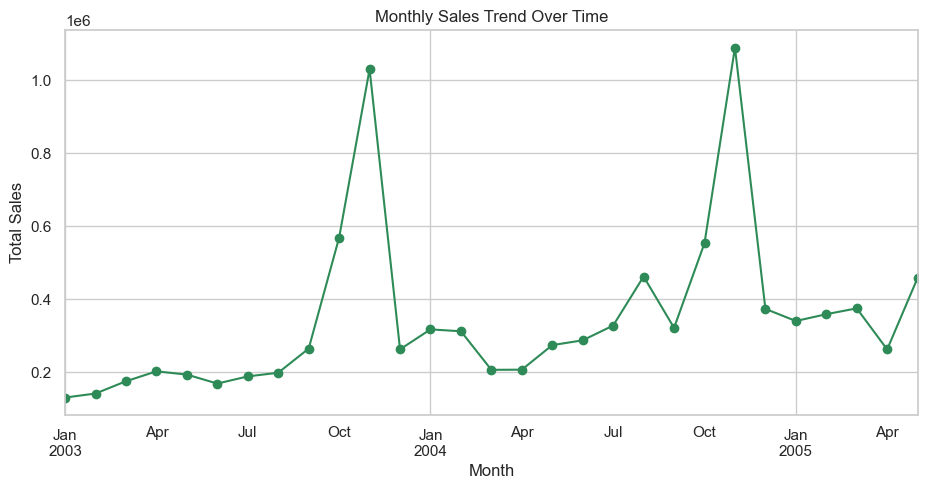

In [14]:
monthly_sales = sales_data.set_index("ORDERDATE")["SALES"].resample("ME").sum()

plt.figure(figsize=(11, 5))
monthly_sales.plot(marker="o", color="#2e8b57")
plt.title("Monthly Sales Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

There is a clear **seasonal spike around November** each year (the festive / holiday season).
This is exactly why the engineered `ORDER_MONTH` feature is useful.

### 7.3 Which product categories sell the most?

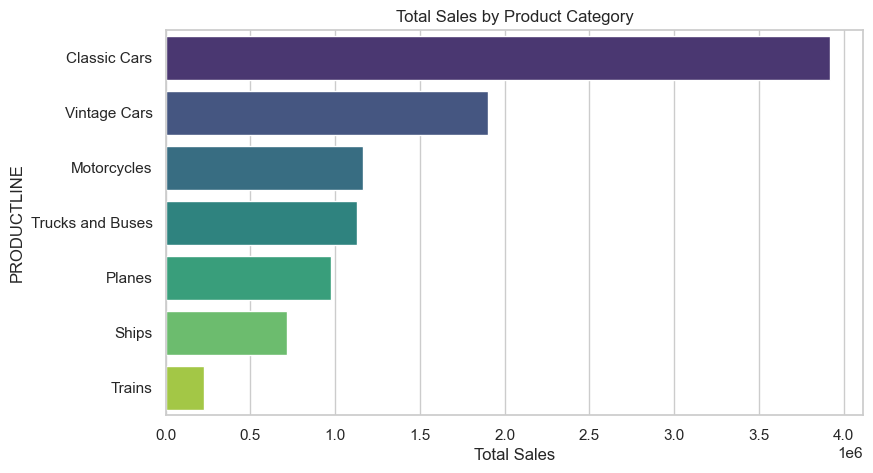

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64

In [15]:
category_sales = sales_data.groupby("PRODUCTLINE")["SALES"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=category_sales.values, y=category_sales.index,
            hue=category_sales.index, palette="viridis", legend=False)
plt.title("Total Sales by Product Category")
plt.xlabel("Total Sales")
plt.show()

category_sales

### 7.4 Which countries buy the most?

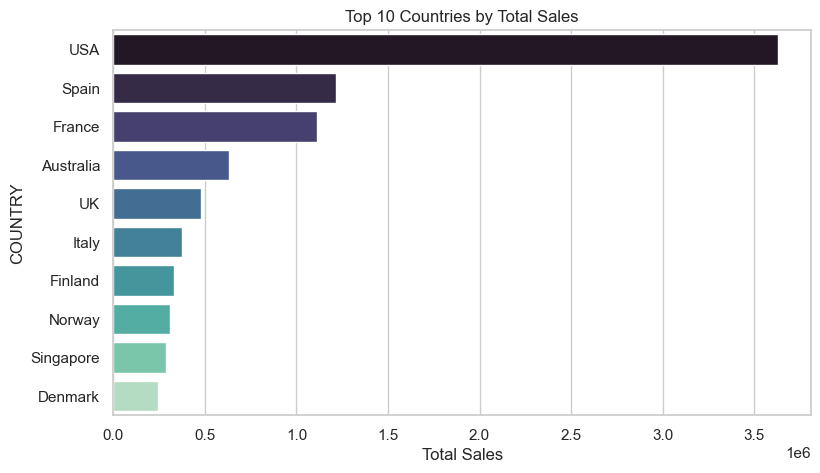

In [16]:
country_sales = sales_data.groupby("COUNTRY")["SALES"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=country_sales.values, y=country_sales.index,
            hue=country_sales.index, palette="mako", legend=False)
plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.show()

### 7.5 Correlation heatmap

A **correlation** value tells us how strongly two numeric columns move together.
+1 means they rise together, -1 means one rises as the other falls, 0 means no linear relationship.

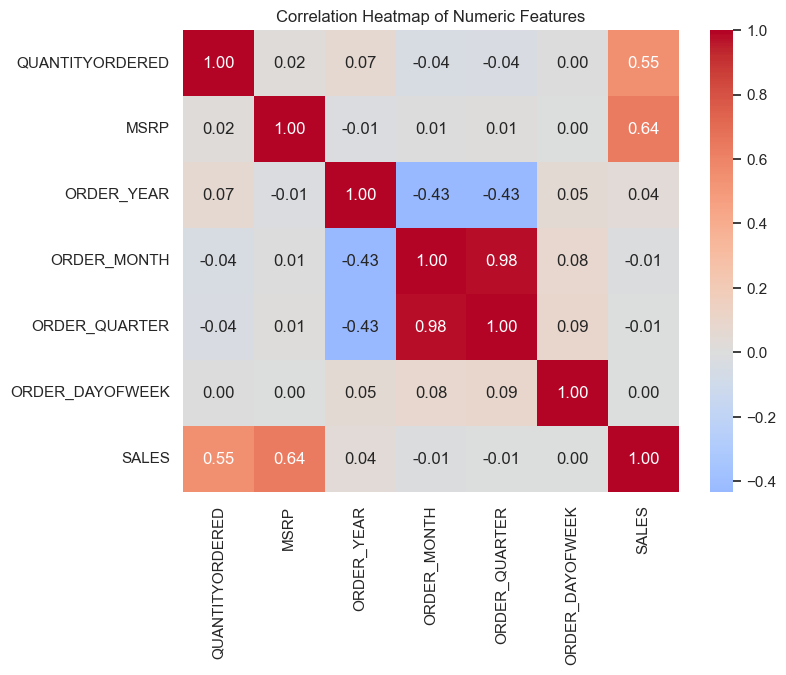

In [17]:
correlation_data = sales_data[numeric_features + [target_column]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

`QUANTITYORDERED` and `MSRP` both have a clear positive correlation with `SALES`, which makes
business sense — more units, or a costlier product, means more revenue. The date features have
almost no *linear* correlation, but tree models can still use them for seasonal patterns.

## Step 8 — Prepare features and split into train / test sets

Machine learning models only understand numbers, so text columns such as `PRODUCTLINE` must be
converted. `pd.get_dummies()` creates one 0/1 column per category — this is called
**one-hot encoding**. We use `drop_first=True` so we do not store the same information twice.

In [18]:
X = pd.get_dummies(
    sales_data[numeric_features + categorical_features],
    columns=categorical_features,
    drop_first=True,
)
y = sales_data[target_column]

print("Number of features after encoding:", X.shape[1])
X.head()

Number of features after encoding: 33


,QUANTITYORDERED,MSRP,ORDER_YEAR,ORDER_MONTH,ORDER_QUARTER,ORDER_DAYOFWEEK,PRODUCTLINE_Motorcycles,PRODUCTLINE_Planes,PRODUCTLINE_Ships,PRODUCTLINE_Trains,...,COUNTRY_Philippines,COUNTRY_Singapore,COUNTRY_Spain,COUNTRY_Sweden,COUNTRY_Switzerland,COUNTRY_UK,COUNTRY_USA,TERRITORY_EMEA,TERRITORY_Japan,TERRITORY_NA
0,30,95,2003,2,1,0,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,34,95,2003,5,2,2,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,41,95,2003,7,3,1,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,45,95,2003,8,3,0,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
4,49,95,2003,10,4,4,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True


We keep **80% of the data for training** and hide **20% for testing**. The test set acts like
"future orders the model has never seen", which is the only fair way to judge a model.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 2258
Testing rows : 565


## Step 9 — Train the three models

- **Linear Regression** fits one straight-line equation through the data.
- **Decision Tree** splits the data using a series of yes/no questions. `max_depth=8` stops the
  tree from growing too deep and memorising the training data (overfitting).
- **Random Forest** builds 200 different decision trees and averages their answers.

In [20]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree":     DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest":     RandomForestRegressor(n_estimators=200, max_depth=12,
                                               random_state=RANDOM_STATE),
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    print("Trained:", model_name)

Trained:

 Linear Regression
Trained: Decision Tree


Trained: Random Forest


## Steps 10 & 11 — Predict and evaluate

The four evaluation metrics:

| Metric | Meaning | Better when |
|---|---|---|
| **MAE** | Mean Absolute Error — the average size of the mistake | Lower |
| **MSE** | Mean Squared Error — average of squared mistakes, punishes big errors more | Lower |
| **RMSE** | Root Mean Squared Error — the square root of MSE, back in sales units | Lower |
| **R²** | How much of the variation in sales the model explains (1.0 = perfect) | Higher |

In [21]:
predictions = {}
results_rows = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    results_rows.append({
        "Model": model_name,
        "MAE":  round(mae, 2),
        "MSE":  round(mse, 2),
        "RMSE": round(rmse, 2),
        "R2":   round(r2, 4),
    })

    print(f"{model_name:<20} MAE={mae:9.2f}  RMSE={rmse:9.2f}  R2={r2:.4f}")

Linear Regression    MAE=   709.68  RMSE=  1158.61  R2=0.6925
Decision Tree        MAE=   722.46  RMSE=  1212.60  R2=0.6631
Random Forest        MAE=   646.58  RMSE=  1063.05  R2=0.7411


## Step 12 — Comparison table

In [22]:
results_table = pd.DataFrame(results_rows)
results_table

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,709.68,1342382.90,1158.61,0.6925
1,Decision Tree,722.46,1470391.31,1212.60,0.6631
2,Random Forest,646.58,1130070.81,1063.05,0.7411


## Step 13 — Identify the best model

The best model is the one with the **highest R²** (it explains the most variation in sales).
Its RMSE should also be the lowest.

In [23]:
best_row = results_table.loc[results_table["R2"].idxmax()]
best_model_name = best_row["Model"]

print("Best performing model:", best_model_name)
print(f"MAE = {best_row['MAE']}, MSE = {best_row['MSE']}, RMSE = {best_row['RMSE']}, R2 = {best_row['R2']}")

Best performing model: Random Forest
MAE = 646.58, MSE = 1130070.81, RMSE = 1063.05, R2 = 0.7411


## Step 14 — Visualise actual vs predicted sales

In these scatter plots, each dot is one test order. The **red dashed line** is the perfect
prediction line. The closer the dots sit to that line, the better the model.

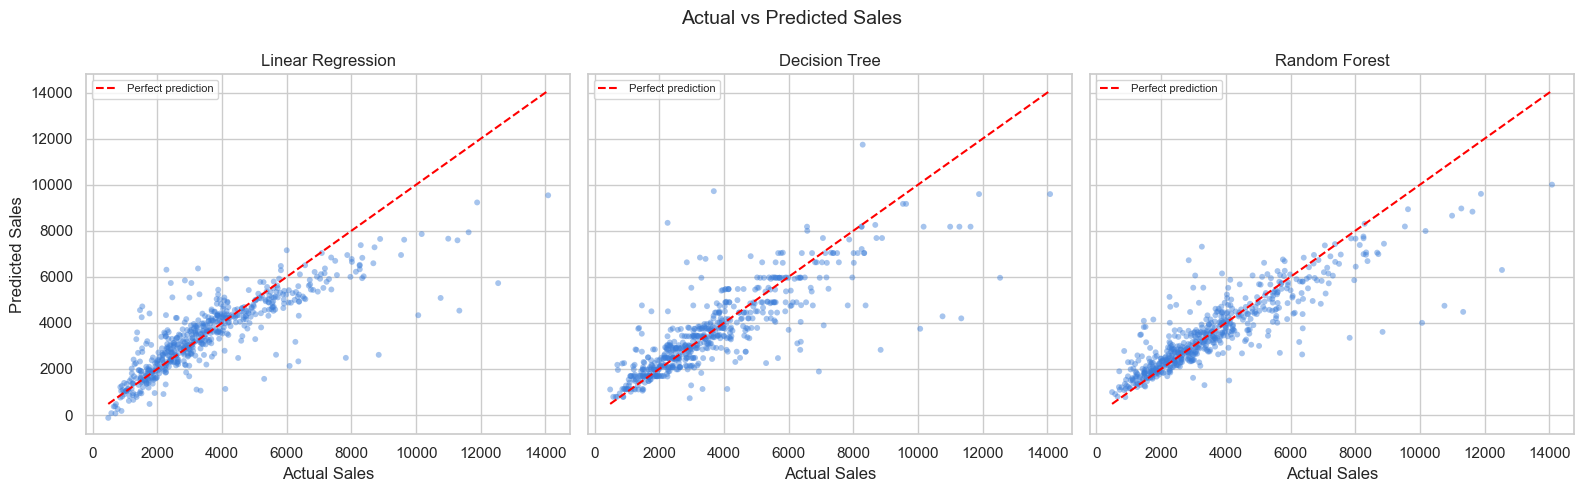

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.45, s=18, color="#3b7dd8", edgecolor="none")
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            color="red", linestyle="--", linewidth=1.5, label="Perfect prediction")
    ax.set_title(model_name)
    ax.set_xlabel("Actual Sales")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Predicted Sales")
fig.suptitle("Actual vs Predicted Sales", fontsize=14)
plt.tight_layout()
plt.show()

Notice the **Decision Tree** plot: its dots form horizontal bands. That is because a tree gives
the *same constant prediction* to every order that falls into the same leaf. Linear Regression
and Random Forest produce smoother, more spread-out predictions.

A line view of the best model on the first 60 test orders is easier to read in a presentation:

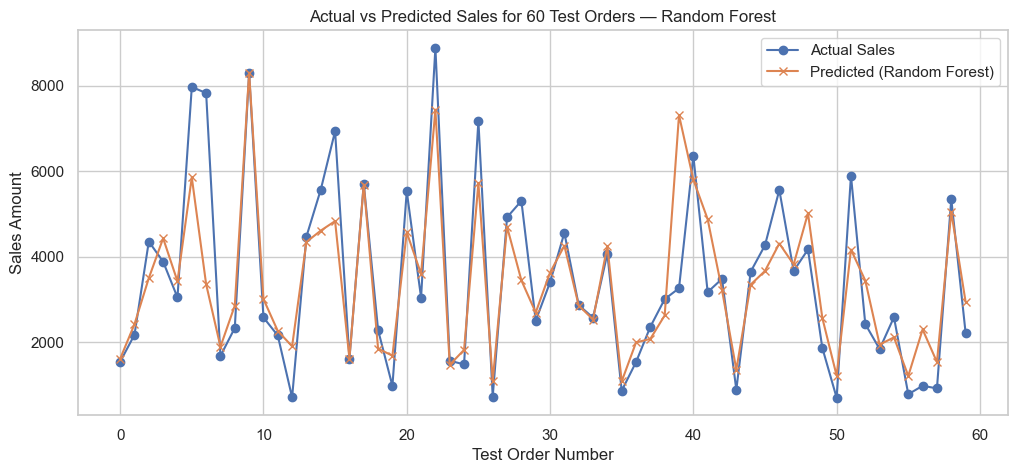

In [25]:
best_predictions = predictions[best_model_name]

plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:60], marker="o", label="Actual Sales")
plt.plot(best_predictions[:60], marker="x", label=f"Predicted ({best_model_name})")
plt.title(f"Actual vs Predicted Sales for 60 Test Orders — {best_model_name}")
plt.xlabel("Test Order Number")
plt.ylabel("Sales Amount")
plt.legend()
plt.show()

## Step 15 — Visualise model performance

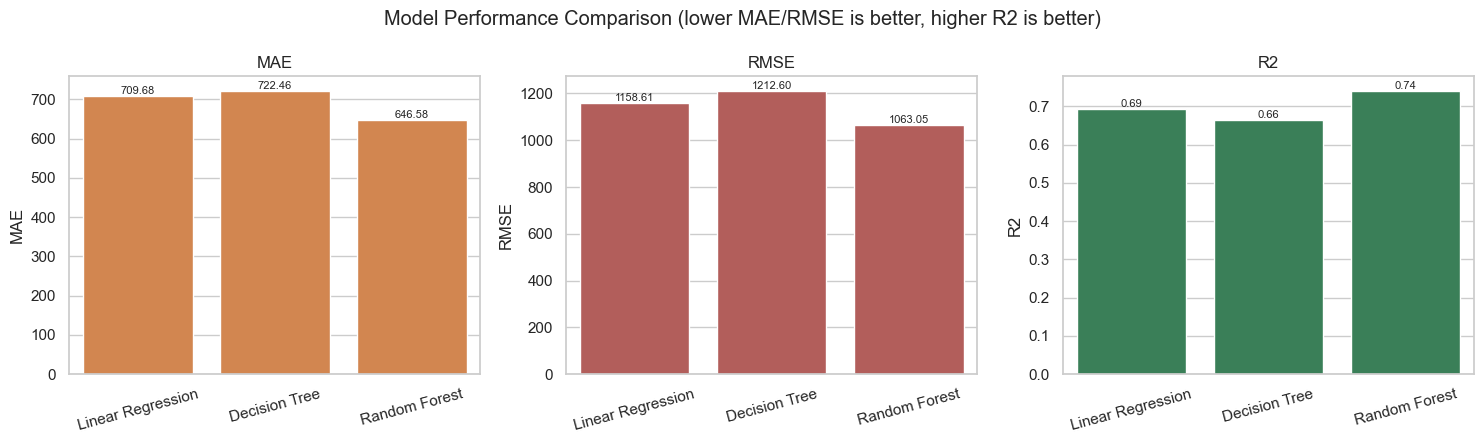

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, metric, color in zip(axes, ["MAE", "RMSE", "R2"], ["#e8833a", "#c0504d", "#2e8b57"]):
    sns.barplot(data=results_table, x="Model", y=metric, ax=ax, color=color)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8)

fig.suptitle("Model Performance Comparison (lower MAE/RMSE is better, higher R2 is better)")
plt.tight_layout()
plt.show()

## Step 16 — Random Forest feature importance

`feature_importances_` tells us how much each feature helped the forest reduce its error.
The scores add up to 1.0, so a score of 0.49 means that feature did 49% of the work.

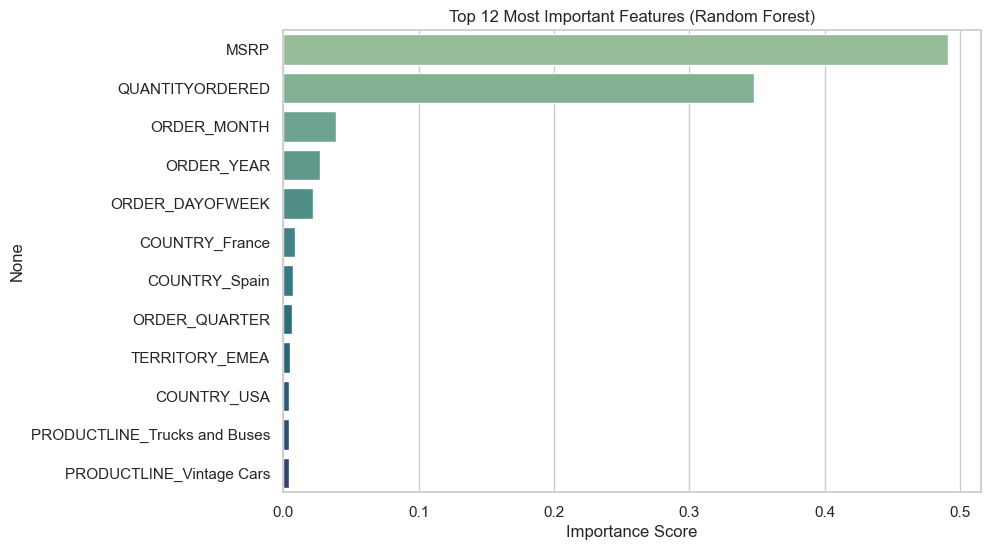

MSRP                            0.490682
QUANTITYORDERED                 0.348061
ORDER_MONTH                     0.039194
ORDER_YEAR                      0.026903
ORDER_DAYOFWEEK                 0.021788
COUNTRY_France                  0.008790
COUNTRY_Spain                   0.007222
ORDER_QUARTER                   0.006407
TERRITORY_EMEA                  0.004900
COUNTRY_USA                     0.004019
PRODUCTLINE_Trucks and Buses    0.003987
PRODUCTLINE_Vintage Cars        0.003912
dtype: float64

In [27]:
random_forest = models["Random Forest"]
importance = pd.Series(random_forest.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_features.values, y=top_features.index,
            hue=top_features.index, palette="crest", legend=False)
plt.title("Top 12 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

top_features

`MSRP` and `QUANTITYORDERED` together account for the large majority of the importance.
This matches business common sense: **revenue ≈ price × quantity**. The date and country
features add smaller refinements.

## Step 17 — Final conclusion

In [28]:
print(results_table.to_string(index=False))
print()
print("BEST MODEL:", best_model_name)

            Model    MAE        MSE    RMSE     R2
Linear Regression 709.68 1342382.90 1158.61 0.6925
    Decision Tree 722.46 1470391.31 1212.60 0.6631
    Random Forest 646.58 1130070.81 1063.05 0.7411

BEST MODEL: Random Forest


### Conclusion

**Random Forest performed the best.** It trains many decision trees on slightly different samples
of the data and averages their answers, so the mistakes of individual trees cancel each other out.
This gives predictions that are both more accurate (highest R², lowest MAE and RMSE) and more
stable than either of the other two models.

**Linear Regression came second.** Sales are roughly price × quantity, and a straight-line model
already captures a good part of that pattern. What it cannot capture is the *multiplying* effect
between price and quantity, or seasonal jumps, so it falls behind the forest.

**A single Decision Tree came last** — a genuinely interesting result. A tree predicts one constant
value for every order in the same leaf, producing a "staircase" of predictions, and it fits the
peculiarities of the training rows more than the general pattern. This is exactly the weakness
that Random Forest fixes by averaging.

**The key lesson of this comparative analysis:** a single decision tree is *not* automatically
better than a simple linear model. It is the **combination of many trees** (the ensemble) that wins.